In [13]:
import time
import random
import copy

TIMESLOTS = ['Mon_9am', 'Mon_10am', 'Tue_9am', 'Tue_10am', 'Wed_9am', 'Wed_10am']
ROOMS = {
    'Room_101': {'capacity': 30, 'facilities': ['projector']},
    'Room_102': {'capacity': 50, 'facilities': ['projector', 'whiteboard']},
    'Lab_A':    {'capacity': 25, 'facilities': ['lab_benches']}
}
PROFESSORS = ['Prof. Ada', 'Prof. Bob', 'Prof. Charles']
GROUPS = ['CS_1stYear', 'CS_2ndYear', 'Math_1stYear']

class Class:
    def __init__(self, id, prof, group, size, facilities_needed):
        self.id = id
        self.prof = prof
        self.group = group
        self.size = size
        self.facilities = facilities_needed

def generate_problem():

    TIMESLOTS_HARD = ['Mon_9am', 'Mon_10am', 'Tue_9am']

    ROOMS_HARD = {
        'Room_101': {'capacity': 30, 'facilities': ['projector']},
        'Room_102': {'capacity': 40, 'facilities': ['projector', 'whiteboard']},
        'Lab_A':    {'capacity': 25, 'facilities': ['lab_benches']}
    }

    classes = [
        Class('CS101', 'Prof. Ada', 'CS_1stYear', 25, ['projector']),
        Class('CS102', 'Prof. Bob', 'CS_1stYear', 25, ['projector']),
        Class('CS103', 'Prof. Ada', 'CS_1stYear', 25, ['projector']),
        Class('Math110', 'Prof. Charles', 'CS_1stYear', 38, ['projector']), # 4th class

        # Other classes to fill up the problem
        Class('Math101', 'Prof. Charles', 'Math_1stYear', 35, ['whiteboard']),
        Class('Math201', 'Prof. Charles', 'Math_1stYear', 35, ['whiteboard']),
        Class('CS201', 'Prof. Ada', 'CS_2ndYear', 20, ['projector']),
        Class('CS210_Lab', 'Prof. Bob', 'CS_2ndYear', 22, ['lab_benches']),
    ]

    # Create the full domain for each class
    initial_domains = {}
    for c in classes:
        c_domain = []
        # Use the HARDER (3-slot) timeslot list
        for t in TIMESLOTS_HARD:
            for r_name, r_details in ROOMS_HARD.items():
                # Unary Constraints (checked at the start)
                if c.size <= r_details['capacity'] and \
                   all(facility in r_details['facilities'] for facility in c.facilities):
                    c_domain.append((t, r_name))

        if not c_domain:
            print(f"Warning: Class {c.id} has NO valid slots from the start.")

        initial_domains[c.id] = c_domain

    return classes, initial_domains

def is_consistent(assignment, new_class, value, all_classes):
    new_time, new_room = value

    # Find the full class objects
    new_class_obj = next(c for c in all_classes if c.id == new_class)

    for assigned_class_id, (assigned_time, assigned_room) in assignment.items():
        # Get the full object for the already assigned class
        assigned_class_obj = next(c for c in all_classes if c.id == assigned_class_id)

        # 1. Room Conflict
        if new_time == assigned_time and new_room == assigned_room:
            return False

        # 2. Professor Conflict
        if new_class_obj.prof == assigned_class_obj.prof and new_time == assigned_time:
            return False

        # 3. Student Group Conflict
        if new_class_obj.group == assigned_class_obj.group and new_time == assigned_time:
            return False

    return True # No conflicts found

def select_unassigned_variable_mrv(unassigned, domains):
    min_len = float('inf')
    chosen_var = None
    for var in unassigned:
        if len(domains[var]) < min_len:
            min_len = len(domains[var])
            chosen_var = var
    return chosen_var

def solve_backtracking(classes, domains, stats):

    assignment = {}
    unassigned = list(domains.keys())

    return backtrack_recursive(assignment, unassigned, classes, domains, stats)

def backtrack_recursive(assignment, unassigned, classes, domains, stats):
    if not unassigned:
        return assignment

    var = select_unassigned_variable_mrv(unassigned, domains)
    unassigned.remove(var)

    for value in domains[var]:
        if is_consistent(assignment, var, value, classes):
            assignment[var] = value

            result = backtrack_recursive(assignment, unassigned, classes, domains, stats)
            if result:
                return result

            # Backtrack
            stats['backtracks'] += 1
            del assignment[var]

    unassigned.insert(0, var)
    return None

def solve_forward_checking(classes, initial_domains, stats):

    domains = copy.deepcopy(initial_domains)
    assignment = {}
    unassigned = list(domains.keys())

    return fc_recursive(assignment, unassigned, classes, domains, stats)

def fc_recursive(assignment, unassigned, classes, domains, stats):
    if not unassigned:
        return assignment

    var = select_unassigned_variable_mrv(unassigned, domains)
    unassigned.remove(var)

    var_obj = next(c for c in classes if c.id == var)

    # Iterate through our *current* (possibly pruned) domain
    for value in list(domains[var]):
        assignment[var] = value
        time, room = value

        # This will hold the domains we need to restore if we backtrack
        pruned_values = {}

        failure = False

        # --- This is the "Forward Checking" part ---
        for neighbor_id in unassigned:
            if failure: break
            neighbor_obj = next(c for c in classes if c.id == neighbor_id)

            # Check for constraints
            prof_conflict = (var_obj.prof == neighbor_obj.prof)
            group_conflict = (var_obj.group == neighbor_obj.group)

            for neighbor_val in list(domains[neighbor_id]): # Iterate a copy
                n_time, n_room = neighbor_val

                # Check for conflicts with the *new* assignment
                room_conflict = (time == n_time and room == n_room)

                if (room_conflict) or \
                   (prof_conflict and time == n_time) or \
                   (group_conflict and time == n_time):

                    # Prune the neighbor's domain
                    domains[neighbor_id].remove(neighbor_val)

                    # Store what we pruned, so we can restore it
                    if neighbor_id not in pruned_values:
                        pruned_values[neighbor_id] = []
                    pruned_values[neighbor_id].append(neighbor_val)

            # If pruning emptied a domain, we have a failure
            if not domains[neighbor_id]:
                failure = True
        if not failure:
            result = fc_recursive(assignment, unassigned, classes, domains, stats)
            if result:
                return result

        # Backtrack
        stats['backtracks'] += 1
        del assignment[var]

        # Restore pruned domains
        for neighbor_id, values in pruned_values.items():
            domains[neighbor_id].extend(values)

    unassigned.insert(0, var)
    return None

if __name__ == "__main__":

    classes, initial_domains = generate_problem()

    print("--- Running Timetable CSP Experiment ---")

    # --- Run Method A ---
    print("\nSolving with Method A: Backtracking + MRV...")
    stats_A = {'backtracks': 0}
    start_time_A = time.perf_counter()
    solution_A = solve_backtracking(classes, initial_domains, stats_A)
    end_time_A = time.perf_counter()

    time_A = (end_time_A - start_time_A) * 1000

    if solution_A:
        print(f"  Solution found in {time_A:.4f} ms")
        print(f"  Backtracks: {stats_A['backtracks']}")
    else:
        print(f"  No solution found. Time: {time_A:.4f} ms, Backtracks: {stats_A['backtracks']}")

    print("\nSolving with Method B: Backtracking + Forward Checking + MRV...")
    stats_B = {'backtracks': 0}
    start_time_B = time.perf_counter()
    solution_B = solve_forward_checking(classes, initial_domains, stats_B)
    end_time_B = time.perf_counter()

    time_B = (end_time_B - start_time_B) * 1000

    if solution_B:
        print(f"  Solution found in {time_B:.4f} ms")
        print(f"  Backtracks: {stats_B['backtracks']}")
    else:
        print(f"  No solution found. Time: {time_B:.4f} ms, Backtracks: {stats_B['backtracks']}")

--- Running Timetable CSP Experiment ---

Solving with Method A: Backtracking + MRV...
  No solution found. Time: 3.3520 ms, Backtracks: 93

Solving with Method B: Backtracking + Forward Checking + MRV...
  No solution found. Time: 0.7471 ms, Backtracks: 39


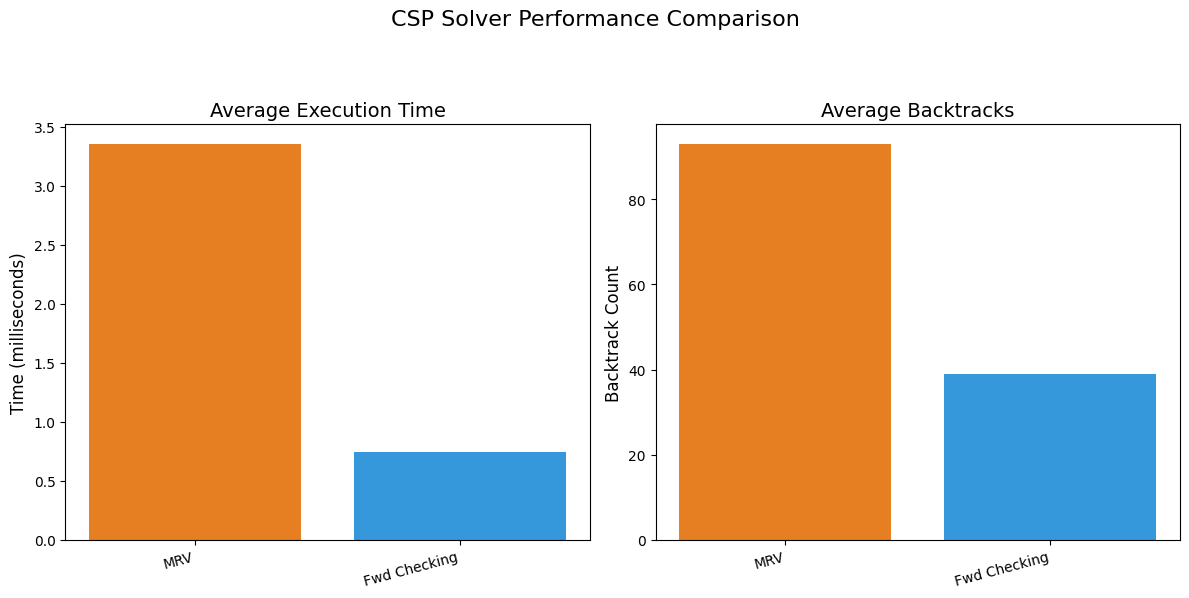

In [14]:
import matplotlib.pyplot as plt

def plot_csp_results(csp_results):

    methods = list(csp_results.keys())
    methods_short = [name.replace("Backtracking + ", "") for name in methods]

    avg_times = [res["avg_time"] for res in csp_results.values()]
    avg_backtracks = [res["avg_backtracks"] for res in csp_results.values()]

    # Create a figure with two subplots, side-by-side
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.bar(methods_short, avg_times, color=['#E67E22', '#3498DB'])
    plt.title('Average Execution Time', fontsize=14)
    plt.ylabel('Time (milliseconds)', fontsize=12)
    plt.xticks(rotation=15, ha="right")
    plt.subplot(1, 2, 2)
    plt.bar(methods_short, avg_backtracks, color=['#E67E22', '#3498DB'])
    plt.title('Average Backtracks', fontsize=14)
    plt.ylabel('Backtrack Count', fontsize=12)
    plt.xticks(rotation=15, ha="right")
    plt.suptitle('CSP Solver Performance Comparison', fontsize=16, y=1.02)

    # Adjust layout to prevent labels from overlapping
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":

    your_csp_data = {
        "Backtracking + MRV": {
            "avg_time": 3.3520,
            "avg_backtracks": 93
        },
        "Backtracking + Fwd Checking": {
            "avg_time":  0.7471,
            "avg_backtracks": 39
        }
    }

    plot_csp_results(your_csp_data)